In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

#1 Сразу переведем столбец "Дата" в правильный формат

In [10]:
# переводим дату в datetime
df['Дата'] = pd.to_datetime(df['Дата'])

# проверяем
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


In [11]:
df.head()

,Дата,Склад,Контрагент,Номенклатура,Количество
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2


#2 Сгруппируйте данные по дате, посчитайте количество продаж

In [12]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


#3 Нарисуйте график продаж у `grouped_df`

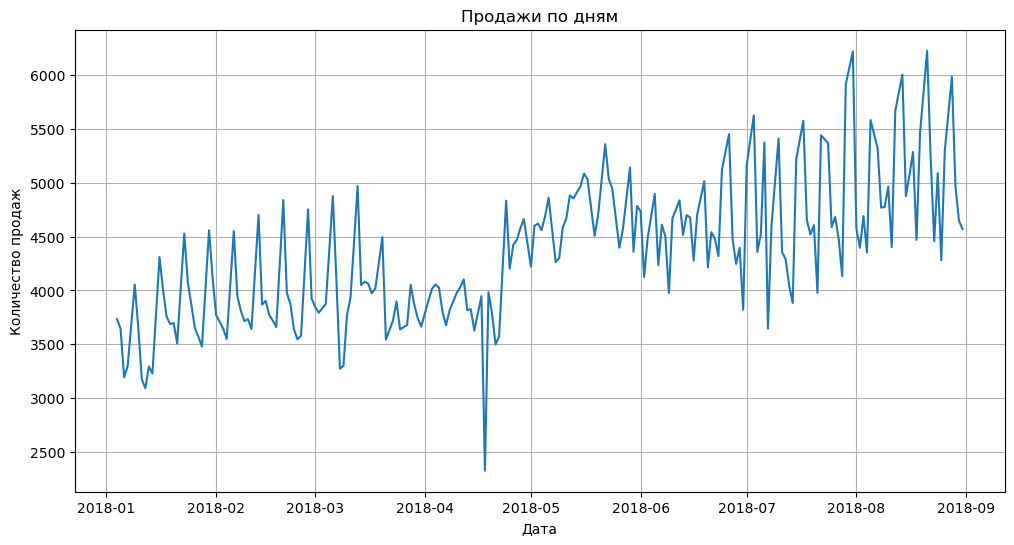

In [13]:
plt.figure(figsize=(12,6))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Продажи по дням')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid()
plt.show()

#4 Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
Есть восходящий тренд — продажи растут от января к августу
Наблюдается чёткая сезонность внутри недели (регулярные пики и спады)
Есть резкие выбросы вниз (например, в апреле сильный провал ~2300)
Во второй половине периода волатильность увеличивается (разброс выше)
Максимальные значения достигают ~6200 → рост бизнеса

#5 Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [14]:
# находим строку с максимальным количеством
outlier = df.loc[df['Количество'].idxmax()]

print(outlier)

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


#5 Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [15]:
# фильтруем склад 3
df_3 = df[df['Склад'] == 3].copy()

# добавляем день недели и месяц
df_3.loc[:, 'weekday'] = df_3['Дата'].dt.weekday
df_3.loc[:, 'month'] = df_3['Дата'].dt.month

# среда = 2 (0=понедельник)
df_wed = df_3[
    (df_3['weekday'] == 2) &
    (df_3['month'].isin([6,7,8]))
]

# группировка по товару
top_product = (
    df_wed.groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

print(top_product)

Номенклатура
product_1    2267
Name: Количество, dtype: int64


#6 Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [41]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [16]:
pip install xlrd==2.0.1

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd

weather = pd.read_excel('weather1.xls', engine='xlrd', skiprows=6)  # если первые 6 строк не таблица
print(weather.head())

  Местное время в Астане     T     Po      P   Pa     U  \
0       31.08.2018 23:00   8.2  736.6  768.3  0.2  78.0   
1       31.08.2018 20:00   9.6  736.4  767.9  1.2  88.0   
2       31.08.2018 17:00  11.3  735.2  766.4  0.4  83.0   
3       31.08.2018 14:00  12.3  734.8  765.9  0.9  80.0   
4       31.08.2018 11:00  13.2  733.9  764.8  1.0  83.0   

                                       DD  Ff  ff10  ff3  ...  \
0          Ветер, дующий с северо-востока   4   NaN  NaN  ...   
1    Ветер, дующий с западо-северо-запада   3   NaN  NaN  ...   
2  Ветер, дующий с востоко-северо-востока   4   NaN  NaN  ...   
3          Ветер, дующий с северо-востока   4   NaN  NaN  ...   
4   Ветер, дующий с северо-северо-востока   4   NaN  NaN  ...   

                                                  Cm  \
0  Высококучевых, высокослоистых или слоисто-дожд...   
1  Высококучевых, высокослоистых или слоисто-дожд...   
2                                                NaN   
3                             

In [10]:
import pandas as pd

# допустим, ваш DataFrame называется weather
weather['Дата'] = pd.to_datetime(
    weather['Местное время в Астане'],
    dayfirst=True,   # у нас формат 31.08.2018
    errors='coerce'  # чтобы некорректные значения стали NaT
)

# проверить результат
print(weather[['Местное время в Астане', 'Дата', 'T']].head())

  Местное время в Астане                Дата     T
0       31.08.2018 23:00 2018-08-31 23:00:00   8.2
1       31.08.2018 20:00 2018-08-31 20:00:00   9.6
2       31.08.2018 17:00 2018-08-31 17:00:00  11.3
3       31.08.2018 14:00 2018-08-31 14:00:00  12.3
4       31.08.2018 11:00 2018-08-31 11:00:00  13.2


In [11]:
print(weather.head())

  Местное время в Астане     T     Po      P   Pa     U  \
0       31.08.2018 23:00   8.2  736.6  768.3  0.2  78.0   
1       31.08.2018 20:00   9.6  736.4  767.9  1.2  88.0   
2       31.08.2018 17:00  11.3  735.2  766.4  0.4  83.0   
3       31.08.2018 14:00  12.3  734.8  765.9  0.9  80.0   
4       31.08.2018 11:00  13.2  733.9  764.8  1.0  83.0   

                                       DD  Ff  ff10  ff3  ...  \
0          Ветер, дующий с северо-востока   4   NaN  NaN  ...   
1    Ветер, дующий с западо-северо-запада   3   NaN  NaN  ...   
2  Ветер, дующий с востоко-северо-востока   4   NaN  NaN  ...   
3          Ветер, дующий с северо-востока   4   NaN  NaN  ...   
4   Ветер, дующий с северо-северо-востока   4   NaN  NaN  ...   

                                                  Ch    VV    Td  \
0  Перистых, перисто-кучевых или перисто-слоистых...   NaN   4.6   
1  Перистых, перисто-кучевых или перисто-слоистых...   NaN   7.7   
2                                                N

In [16]:
# создаём колонку только с датой без времени
weather['День'] = weather['Дата'].dt.date

# группируем по дню и считаем среднюю температуру
daily_weather = weather.groupby('День')['T'].mean().reset_index()
daily_weather.rename(columns={'T': 'T_avg'}, inplace=True)
print(daily_weather.head())

         День    T_avg
0  2018-01-04 -14.0750
1  2018-01-05 -16.8625
2  2018-01-06 -13.3000
3  2018-01-07 -12.7500
4  2018-01-08 -15.4125


In [12]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.date

In [17]:
merged_df = grouped_df.merge(daily_weather, left_on='Дата', right_on='День', how='left')
print(merged_df.head())

         Дата  Склад Контрагент Номенклатура  Количество   Дата_only  \
0  2018-01-04      1  address_0    product_0           4  2018-01-04   
1  2018-01-04      1  address_0    product_1           4  2018-01-04   
2  2018-01-04      1  address_0    product_2           5  2018-01-04   
3  2018-01-04      1  address_0    product_3          10  2018-01-04   
4  2018-01-04      1  address_0    product_4           2  2018-01-04   

         День   T_avg  
0  2018-01-04 -14.075  
1  2018-01-04 -14.075  
2  2018-01-04 -14.075  
3  2018-01-04 -14.075  
4  2018-01-04 -14.075  


In [18]:
# В grouped_df оставляем только дату без времени
grouped_df['Дата_only'] = pd.to_datetime(grouped_df['Дата']).dt.date

# В daily_weather тоже должны быть date
daily_weather['День'] = pd.to_datetime(daily_weather['День']).dt.date

# Теперь merge
merged_df = grouped_df.merge(daily_weather, left_on='Дата_only', right_on='День', how='left')

print(merged_df[['Дата', 'Количество', 'T_avg']].head(10))

         Дата  Количество   T_avg
0  2018-01-04           4 -14.075
1  2018-01-04           4 -14.075
2  2018-01-04           5 -14.075
3  2018-01-04          10 -14.075
4  2018-01-04           2 -14.075
5  2018-01-04           2 -14.075
6  2018-01-04           0 -14.075
7  2018-01-04           1 -14.075
8  2018-01-04           1 -14.075
9  2018-01-04           0 -14.075


In [16]:
# Сначала приведём Местное время к datetime
weather['Дата'] = pd.to_datetime(weather['Местное время в Астане'], dayfirst=True)

# Считаем среднюю температуру по дню
daily_weather = weather.groupby(weather['Дата'].dt.date).agg(T_avg=('T','mean')).reset_index()
daily_weather.rename(columns={'Дата':'День'}, inplace=True)

In [17]:
# В grouped_df оставляем только дату
grouped_df['Дата_only'] = pd.to_datetime(grouped_df['Дата']).dt.date

# Merge по датам
merged_df = grouped_df.merge(daily_weather, left_on='Дата_only', right_on='День', how='left')

# Проверим результат
print(merged_df[['Дата','Количество','T_avg']].head(10))

         Дата  Количество  T_avg
0  2018-01-04        3734    NaN
1  2018-01-05        3643    NaN
2  2018-01-06        3193    NaN
3  2018-01-07        3298    NaN
4  2018-01-09        4055    NaN
5  2018-01-10        3653    NaN
6  2018-01-11        3176    NaN
7  2018-01-12        3092    NaN
8  2018-01-13        3294    NaN
9  2018-01-14        3228    NaN


In [19]:
# В grouped_df оставляем только дату без времени
grouped_df['Дата_only'] = pd.to_datetime(grouped_df['Дата']).dt.date

# В daily_weather тоже только дата
daily_weather['День'] = pd.to_datetime(daily_weather['День']).dt.date

In [20]:
print(set(grouped_df['Дата_only']) & set(daily_weather['День']))

{datetime.date(2018, 2, 28), datetime.date(2018, 4, 26), datetime.date(2018, 8, 29), datetime.date(2018, 4, 19), datetime.date(2018, 6, 29), datetime.date(2018, 3, 23), datetime.date(2018, 1, 4), datetime.date(2018, 2, 7), datetime.date(2018, 8, 10), datetime.date(2018, 7, 6), datetime.date(2018, 2, 9), datetime.date(2018, 5, 24), datetime.date(2018, 7, 28), datetime.date(2018, 5, 31), datetime.date(2018, 1, 27), datetime.date(2018, 6, 19), datetime.date(2018, 1, 31), datetime.date(2018, 5, 10), datetime.date(2018, 6, 22), datetime.date(2018, 5, 18), datetime.date(2018, 4, 13), datetime.date(2018, 1, 17), datetime.date(2018, 2, 22), datetime.date(2018, 7, 3), datetime.date(2018, 8, 4), datetime.date(2018, 3, 3), datetime.date(2018, 3, 7), datetime.date(2018, 7, 26), datetime.date(2018, 8, 7), datetime.date(2018, 2, 21), datetime.date(2018, 4, 1), datetime.date(2018, 8, 1), datetime.date(2018, 2, 10), datetime.date(2018, 3, 8), datetime.date(2018, 8, 3), datetime.date(2018, 2, 6), datet

In [21]:
# оставляем только даты, для которых есть погода
sales_filtered = grouped_df[grouped_df['Дата_only'].isin(daily_weather['День'])]

In [22]:
merged_df = sales_filtered.merge(
    daily_weather[['День','T_avg']], 
    left_on='Дата_only', 
    right_on='День', 
    how='left'
)

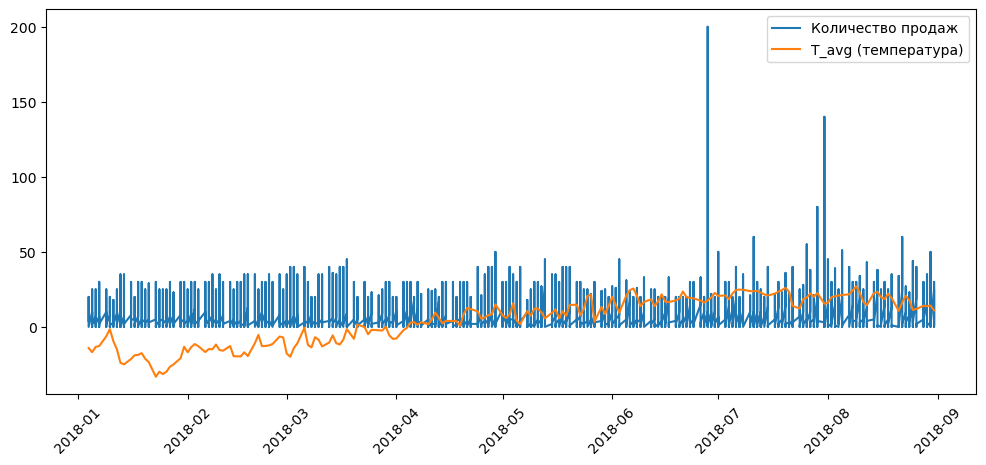

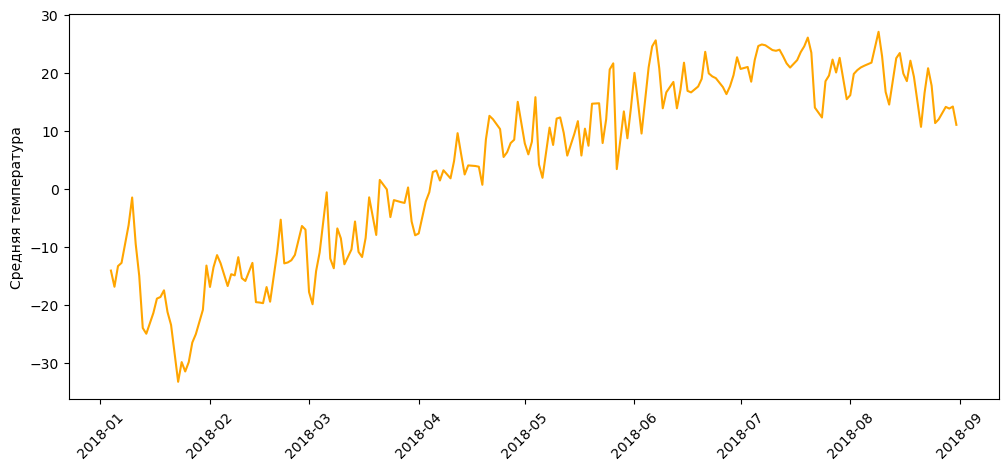

In [23]:
import matplotlib.pyplot as plt

# График Продажи и Температура
plt.figure(figsize=(12,5))
plt.plot(merged_df['Дата_only'], merged_df['Количество'], label='Количество продаж')
plt.plot(merged_df['Дата_only'], merged_df['T_avg'], label='T_avg (температура)')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Только график температуры
plt.figure(figsize=(12,5))
plt.plot(merged_df['Дата_only'], merged_df['T_avg'], color='orange')
plt.xticks(rotation=45)
plt.ylabel('Средняя температура')
plt.show()

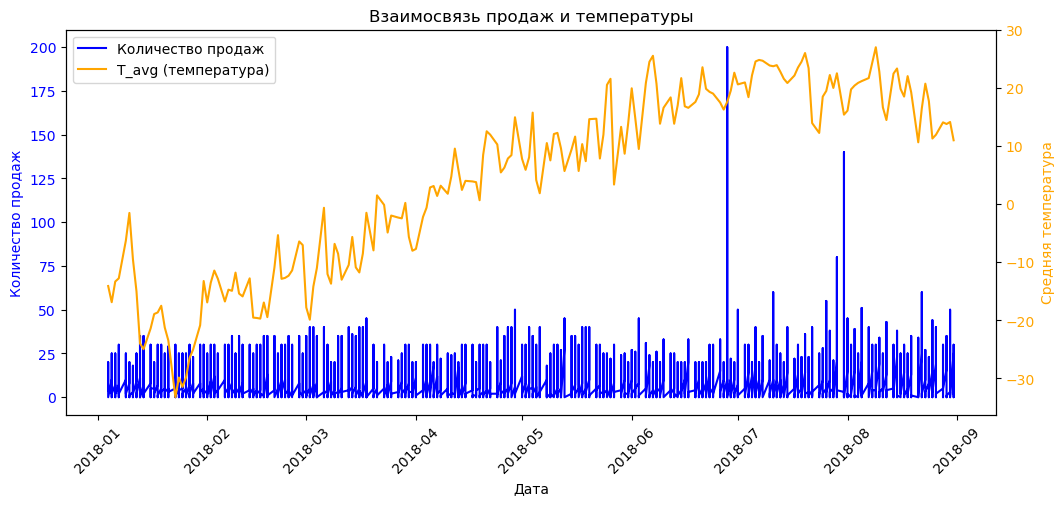

In [24]:
import matplotlib.pyplot as plt

# Создаем фигуру и основную ось
fig, ax1 = plt.subplots(figsize=(12,5))

# График продаж на основной оси Y
ax1.plot(merged_df['Дата_only'], merged_df['Количество'], color='blue', label='Количество продаж')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x', rotation=45)

# Создаем вторую ось Y для температуры
ax2 = ax1.twinx()
ax2.plot(merged_df['Дата_only'], merged_df['T_avg'], color='orange', label='T_avg (температура)')
ax2.set_ylabel('Средняя температура', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Добавим легенду
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Взаимосвязь продаж и температуры')
plt.show()